# init

In [ ]:
PDF_export_active = False

In [1]:
import sled_ROI_tools
import sled_general_tools
import sled_stat_tools
import sled_image_tools
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pickle
import os
import sys
import jsimg as jsi
import ttracking as tt
import js_manuscript as jsm
import copy
import glob
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from scipy.stats import ttest_ind
from matplotlib import animation
from matplotlib.animation import FuncAnimation
import statsmodels.api as sm
import matplotlib as mpl
from scipy import stats
from scipy.stats import pearsonr
import importlib
import time
from sklearn.linear_model import LinearRegression
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42

In [2]:
trialStart = 0.15
sampleEnd = trialStart+1.2
delayEnd = sampleEnd+1.25
figSaveDir = "/export/general/pooledData/Calcium/JS_figsPanels/Fig5"
mdDir = '/home/range6-raid3/scheij/Documents/Data/mainDS'
mdTitle = 'allSlim3'
masterData = pickle.load(open(fr'{mdDir}/{mdTitle}.p', 'rb'))
anms = list(masterData.keys())
anatKeys = ['dendrites', 'somas']
frs = [44.6, 22.8]

In [3]:
dffKeys = ['consensus_NMFtc_dff_bc_decon_sp_events']
factors = [10,5]
Z = 'std_only'
phases2 = ['pre', 'preShift_early', 'preShift_late', 'post', 'late', 'day-1_beg', 'day-1_mid', 'day-1_end', 'shiftDay_post', 'shiftDay_pre', 'early'] 
windowSize = []
importlib.reload(jsm)
allAnmParams = jsm.get_allAnmParams2(masterData, anms, frs, factors, Z, phases2, dffKeys)

0 B00002121749
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:184: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript2.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript2.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript2.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


phase: early, days used: [0, 2]
1 B00002121774
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:184: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript2.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript2.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript2.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002121774 07-Oct-2022 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121774 sess0 07-Oct-2022 len(trial_frames) = 305 len(tsep_sess) = 306
<<WARNING>> [tsep_traces()] B00002121774 09-Oct-2022 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121774 sess1 09-Oct-2022 len(trial_frames) = 284 len(tsep_sess) = 285
phase: early, days used: [0, 1]


...

/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:184: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript2.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript2.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript2.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
phase: early, days used: [0, 1]
21 B00002214001
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript2.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript2.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript2.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
phase: early, days used: [0, 1]


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/ttracking.py:1785: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


In [4]:
dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'
thrsh = 0.05
minTrials = 5
anatKeys = ['dendrites', 'somas']
importlib.reload(jsm)
aAnms, keepRoisFull, keepRoisDS, allNaNs = jsm.check_anms_ROIs(allAnmParams, anms, anatKeys, dffKey, thrsh)
aAnms, iAnms, anmsMinTrial, allMinTrials = jsm.check_trials(allAnmParams, anms, anatKeys, dffKey, minTrials)

full
dendrites 327 / 402 0.813
somas 479 / 528 0.907

dendrites B00002121774 334 264 74 15
dendrites B00002213772 350 361 34 72
dendrites B00002213773 190 196 32 67
dendrites B00002213784 308 260 20 23
dendrites B00002213785 271 264 43 68
dendrites B00002213908 266 242 43 41
dendrites B00002213909 337 306 142 47
dendrites B00002213921 254 301 51 47
dendrites B00002213932 368 466 10 158
dendrites B00002213943 311 340 24 50
dendrites B00002213944 169 145 62 10
dendrites B00002213970 364 319 173 8
dendrites B00002213997 237 139 267 6
dendrites B00002213998 366 28 148 17
dendrites B00002213999 338 271 49 7
somas B00002121749 164 41 45 15
somas B00002121774 238 229 58 35
somas B00002213772 258 288 25 74
somas B00002213773 107 80 18 19
somas B00002213784 274 261 15 6
somas B00002213785 235 250 25 49
somas B00002213889 321 229 59 22
somas B00002213908 270 227 103 73
somas B00002213909 251 198 142 18
somas B00002213921 281 290 23 20
somas B00002213943 286 275 29 20
somas B00002213997 187 83 25

# preCalc megaTsep and CDs

In [5]:
iAnms = {}
aAnms = {}
minTrials = 10
for anat in anatKeys:
    iAnms[anat] = []
    aAnms[anat] = []
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            aAnms[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            cTimes = allAnmParams[anm]['cTimes']
            goCues = allAnmParams[anm]['goCues']
            preMask = allAnmParams[anm]['shiftMask']['pre']
            postMask = allAnmParams[anm]['shiftMask']['post']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            me = allAnmParams[anm]['me']
            de = allAnmParams[anm]['de']
            ar = allAnmParams[anm]['afterRight']
            al = allAnmParams[anm]['afterLeft']
            an = allAnmParams[anm]['afterNone']
            ln = np.logical_or(al, an)

            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            preAnatMask = np.logical_and(anatMask, preMask)
            postAnatMask = np.logical_and(anatMask, postMask)
            pretkr = tracker[preAnatMask,:]
            posttkr = tracker[postAnatMask,:]
            postME = me[postAnatMask]
            postDE = de[postAnatMask]
            postAR = ar[postAnatMask]
            postAL = al[postAnatMask]
            postAN = an[postAnatMask]
            postLN = ln[postAnatMask]
            
            pCR = np.sum(posttkr[:,2]==0)
            pCL = np.sum(posttkr[:,2]==1)
            pMER = np.sum(np.logical_and(postME, posttkr[:,2]==5))
            pDER = np.sum(np.logical_and(postDE, posttkr[:,2]==5))
            pAR = np.sum(postAR)
            pAL = np.sum(postAL)
            pAN = np.sum(postAN)
            pNL = np.sum(postLN)
            ftsep = allAnmParams[anm][dffKey]['fullTsep'][anat]['full']
            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            if pAR>minTrials and pCR>minTrials:
                if anm != 'B00002121777':
                    if ftsep.shape[1]>=10:
                        iAnms[anat].append(anm)
                        print(anat, anm, np.sum(pAR), np.sum(pAL), np.sum(pCR))
print(iAnms)

dendrites B00002121774 93 4 295
dendrites B00002213772 31 17 311
dendrites B00002213784 26 5 377
dendrites B00002213785 44 17 166
dendrites B00002213908 36 42 178
dendrites B00002213932 66 19 253
dendrites B00002213970 269 195 130
dendrites B00002213982 176 98 170
dendrites B00002213997 295 35 228
dendrites B00002213998 202 50 233
dendrites B00002213999 86 54 365
somas B00002121749 25 25 113
somas B00002121774 160 17 237
somas B00002213772 29 35 432
somas B00002213784 28 8 243
somas B00002213889 16 7 226
somas B00002213908 53 21 336
somas B00002213982 108 5 225
somas B00002213985 29 4 143
somas B00002213997 124 14 169
somas B00002213999 47 64 276
somas B00002214001 78 32 161
{'dendrites': ['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785', 'B00002213908', 'B00002213932', 'B00002213970', 'B00002213982', 'B00002213997', 'B00002213998', 'B00002213999'], 'somas': ['B00002121749', 'B00002121774', 'B00002213772', 'B00002213784', 'B00002213889', 'B00002213908', 'B00002213982', 'B

In [6]:
iAnms2 = {}
aAnms2 = {}
minTrials = 100
anmsMinTrial = {}
for anat in anatKeys:
    iAnms2[anat] = []
    aAnms2[anat] = []
    anmsMinTrial[anat] = {}
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            aAnms2[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            preMask = allAnmParams[anm]['shiftMask']['pre']
            postMask = allAnmParams[anm]['shiftMask']['post']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            me = allAnmParams[anm]['me']
            de = allAnmParams[anm]['de']

            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            preAnatMask = np.logical_and(anatMask, preMask)
            postAnatMask = np.logical_and(anatMask, postMask)
            pretkr = tracker[preAnatMask,:]
            posttkr = tracker[postAnatMask,:]
            pCR = np.sum(posttkr[:,2]==0)
            pCL = np.sum(posttkr[:,2]==1)
            preCR = np.sum(pretkr[:,2]==0)
            preCL = np.sum(pretkr[:,2]==1)
            ftsep = allAnmParams[anm][dffKey]['fullTsep'][anat]['full']
            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            if np.all(np.hstack([item>minTrials for item in [pCR, pCL, preCR, preCL]])):
                if anm != 'B00002121777':
                    if ftsep.shape[1]>=10:
                        iAnms2[anat].append(anm)
                        print(anat, anm, np.sum(pCR),np.sum(pCL))
                        anmsMinTrial[anat][anm] = np.min(np.hstack([pCR, pCL, preCR, preCL]))
print(iAnms2)

dendrites B00002121774 295 244
dendrites B00002213772 311 199
dendrites B00002213784 377 254
dendrites B00002213785 166 141
dendrites B00002213908 178 138
dendrites B00002213920 245 226
dendrites B00002213932 253 210
dendrites B00002213970 130 294
dendrites B00002213982 170 175
dendrites B00002213985 248 250
dendrites B00002213997 228 177
dendrites B00002213999 365 268
somas B00002121774 237 224
somas B00002213772 432 223
somas B00002213784 243 180
somas B00002213785 166 140
somas B00002213889 226 139
somas B00002213908 336 222
somas B00002213920 229 199
somas B00002213982 225 200
somas B00002213999 276 190
somas B00002214001 161 199
{'dendrites': ['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785', 'B00002213908', 'B00002213920', 'B00002213932', 'B00002213970', 'B00002213982', 'B00002213985', 'B00002213997', 'B00002213999'], 'somas': ['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785', 'B00002213889', 'B00002213908', 'B00002213920', 'B00002213982', 'B0000221399

In [7]:
for ak, anat in enumerate(anatKeys):
    anms1 = iAnms[anat]
    anms2 = iAnms2[anat]
    print(anat, f'MER {len(anms1)}', f'Motor {len(anms2)}', f'Both {np.sum(np.isin(anms1, anms2))}')

dendrites MER 11 Motor 12 Both 10
somas MER 11 Motor 10 Both 8


In [8]:
bothAnms = {}
for ak, anat in enumerate(anatKeys):
    anms1 = iAnms[anat]
    anms2 = iAnms2[anat]
    print(anat, f'MER {len(anms1)}', f'Motor {len(anms2)}', f'Both {np.sum(np.isin(anms1, anms2))}')
    bothAnms[anat] = np.hstack(anms1)[np.isin(anms1, anms2)]
bothAnms

dendrites MER 11 Motor 12 Both 10
somas MER 11 Motor 10 Both 8


{'dendrites': array(['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785',
        'B00002213908', 'B00002213932', 'B00002213970', 'B00002213982',
        'B00002213997', 'B00002213999'], dtype='<U12'),
 'somas': array(['B00002121774', 'B00002213772', 'B00002213784', 'B00002213889',
        'B00002213908', 'B00002213982', 'B00002213999', 'B00002214001'],
       dtype='<U12')}

In [9]:
for ak, anat in enumerate(anatKeys):
    akSum = 0
    for anm in bothAnms[anat]:
        akSum+=np.sum(keepRoisDS[anat][anm])
    print(anat, akSum)

dendrites 167
somas 179


In [10]:
iAnms = {}
aAnms = {}
minTrials = 5
percs = {}
for anat in anatKeys:
    iAnms[anat] = []
    aAnms[anat] = []
    percs[anat] = []
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            aAnms[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            cTimes = allAnmParams[anm]['cTimes']
            goCues = allAnmParams[anm]['goCues']
            preMask = allAnmParams[anm]['shiftMask']['pre']
            postMask = allAnmParams[anm]['shiftMask']['post']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            me = allAnmParams[anm]['me']
            de = allAnmParams[anm]['de']
            ar = allAnmParams[anm]['afterRight']
            al = allAnmParams[anm]['afterLeft']
            an = allAnmParams[anm]['afterNone']
            merl_me = allAnmParams[anm]['MER-L_ME']
            merl_nome = allAnmParams[anm]['MER-L_noME']
            
            slN = allAnmParams[anm]['sl_nHits']
            
            ln = np.logical_or(al, an)

            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            preAnatMask = np.logical_and(anatMask, preMask)
            postAnatMask = np.logical_and(anatMask, postMask)
            pretkr = tracker[preAnatMask,:]
            posttkr = tracker[postAnatMask,:]
            postME = me[postAnatMask]
            postDE = de[postAnatMask]
            postAR = ar[postAnatMask]
            postAL = al[postAnatMask]
            postAN = an[postAnatMask]
            postLN = ln[postAnatMask]
            
            pCR = np.sum(posttkr[:,2]==0)
            pCL = np.sum(posttkr[:,2]==1)
            pMER = np.sum(np.logical_and(postME, posttkr[:,2]==5))
            pDER = np.sum(np.logical_and(postDE, posttkr[:,2]==5))
            pAR = np.sum(postAR)
            pAL = np.sum(postAL)
            pAN = np.sum(postAN)
            pNL = np.sum(postLN)

            pHit = np.sum(np.logical_and(slN[postAnatMask]>0, postME))
            pMiss = np.sum(np.logical_and(slN[postAnatMask]==0, postME))

            hitP = np.sum(pHit)/np.sum(postME)
            missP = np.sum(pMiss)/np.sum(postME)

            MERL_ME = np.sum(merl_me[postMask])
            MERL_noME = np.sum(merl_nome[postMask])
            ftsep = allAnmParams[anm][dffKey]['fullTsep'][anat]['full']
            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            if pAR>minTrials and pCR>minTrials and MERL_ME>minTrials and MERL_noME>minTrials:# and pHit>minTrials and pMiss>minTrials:# and pAL>minTrials:# and anmLearn[anm]==(1,0,0):
            #if pMER>minTrials and pCR>minTrials:
                if anm != 'B00002121777':
                    if ftsep.shape[1]>=10:
                        iAnms[anat].append(anm)
                        print(anat, anm, np.sum(pAR), np.sum(pAL), np.sum(pCR))
                        percs[anat].append([hitP,missP])
print(iAnms)

dendrites B00002121774 93 4 295
dendrites B00002213772 31 17 311
dendrites B00002213908 36 42 178
dendrites B00002213932 66 19 253
dendrites B00002213997 295 35 228
dendrites B00002213998 202 50 233
dendrites B00002213999 86 54 365
somas B00002121749 25 25 113
somas B00002121774 160 17 237
somas B00002213772 29 35 432
somas B00002213908 53 21 336
somas B00002213997 124 14 169
somas B00002213999 47 64 276
somas B00002214001 78 32 161
{'dendrites': ['B00002121774', 'B00002213772', 'B00002213908', 'B00002213932', 'B00002213997', 'B00002213998', 'B00002213999'], 'somas': ['B00002121749', 'B00002121774', 'B00002213772', 'B00002213908', 'B00002213997', 'B00002213999', 'B00002214001']}


/tmp/ipykernel_3404518/2383533234.py:60: RuntimeWarning: invalid value encountered in long_scalars
  hitP = np.sum(pHit)/np.sum(postME)
/tmp/ipykernel_3404518/2383533234.py:61: RuntimeWarning: invalid value encountered in long_scalars
  missP = np.sum(pMiss)/np.sum(postME)


In [11]:
importlib.reload(jsm)
psWindow = [-3.6,3.6]
useDS = True
dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'
#anmsToUse = iAnms
anmsToUse = bothAnms
shuffAnms = True
shuffRois = False
enforceMinTrial = False
nTriToDraw = 50
binary = False
giveAll = True

allAnms = np.unique(np.hstack([anmsToUse[anat] for anat in anatKeys]))
phases = ['pre','post']
pLabels = ['pre','post']
mods = ['errGO', 'errCT', 'errSL']#, 'errLL']
alignTimes = ['goCues','cTimes','secondLick']#,'lastLick']

nBoot = 10000
megaTseps = {}
megaTsepsHH = {}
emptyMegaTsep = {'dendrites': [], 'somas': []}

for p, phase in enumerate(phases):
    megaTseps[phase] = {}
    megaTsepsHH[f'{phase}1'] = {}
    megaTsepsHH[f'{phase}2'] = {}
    for mod in mods:
        megaTseps[phase][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}1'][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}2'][mod] = copy.deepcopy(emptyMegaTsep)

#making holder matracies
somaTime = allAnmParams[anmsToUse['somas'][0]][dffKey]['dsTsep']['somas']['go-psTsep'].shape[2]
nSoma = 0
for anm in anmsToUse['somas']:
    nSoma+=allAnmParams[anm][dffKey]['dsTsep']['somas']['go-psTsep'][:,keepRoisDS['somas'][anm],:].shape[1]
    
dendTime = allAnmParams[anmsToUse['dendrites'][0]][dffKey]['dsTsep']['dendrites']['go-psTsep'].shape[2]
nDend = 0
for anm in anmsToUse['dendrites']:
    nDend+=allAnmParams[anm][dffKey]['dsTsep']['dendrites']['go-psTsep'][:,keepRoisDS['dendrites'][anm],:].shape[1]
    
if giveAll:
    nTri = 10
else:
    nTri = 4
somaEmpty = np.empty([nTri, somaTime, nSoma, nBoot])
dendEmpty = np.empty([nTri, dendTime, nDend, nBoot])
empties = [dendEmpty, somaEmpty]
for phase in phases:
    for mod in mods:
        for ak, anat in enumerate(anatKeys):
            megaTseps[phase][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}1'][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}2'][mod][anat] = copy.deepcopy(empties[ak])

## important loop
for i in tqdm(range(nBoot)):
    for ak, anat in enumerate(anatKeys):
        if shuffAnms:
            anmIdxs = np.random.choice(np.arange(len(anmsToUse[anat])), len(anmsToUse[anat]))
        else:
            anmIdxs = np.arange(len(anmsToUse[anat]))
        nRois = np.sum(np.hstack([np.sum(keepRoisDS[anat][anm]) for anm in anmsToUse[anat]]))
        for m, mod in enumerate(mods):
            mT1, mT2 = jsm.gather_anmShuff_megaTsepHH_ALT(allAnmParams, anat, ak, mod, phases, frs, keepRoisDS, keepRoisFull, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, nTriToDraw, binary, useDS, giveAll)
            for phase in phases:
                megaTsepsHH[f'{phase}1'][mod][anat][:,:,:,i] = mT1[phase]
                megaTsepsHH[f'{phase}2'][mod][anat][:,:,:,i] = mT2[phase]

  0%|          | 0/10000 [00:00<?, ?it/s]

/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:1074: RuntimeWarning: Mean of empty slice
  SLL = np.nanmean(psTsep[SLLt,:,:], axis = 0)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:1069: RuntimeWarning: Mean of empty slice
  SLR = np.nanmean(psTsep[SLRt,:,:], axis = 0)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:1085: RuntimeWarning: Mean of empty slice
  NSH = np.nanmean(psTsep[NSHt,:,:], axis = 0)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:1141: RuntimeWarning: Mean of empty slice
  AN = np.nanmean(psTsep[ANt,:,:], axis = 0)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:1101: RuntimeWarning: Mean of empty slice
  DE = np.nanmean(psTsep[DEt,:,:], axis = 0)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:1125: RuntimeWarning: Mean of empty slice
  AL_ME = np.nanmean(psTsep[al_MEt,:,:], axis = 0)
/home/range6-raid17/kerlinlab/sled/sled-klab/p

In [12]:
for ak, anat in enumerate(anatKeys):
    print(anat, len(bothAnms[anat]))
    print(megaTsepsHH['post1']['errCT'][anat].shape)
    print((1/frs[ak])*factors[ak])
    print('')

dendrites 10
(10, 32, 167, 10000)
0.22421524663677128

somas 8
(10, 34, 179, 10000)
0.21929824561403508



# paper text quants

In [13]:
### both ports touched on contact lick

allTrialDoubles = []
CADoubles = []

for anm in anms:

    anmParams = allAnmParams[anm]
    anmData = masterData[anm]
    bpodLicks = tt.get_lickTimes(anmData['behavior'])
    cTimes = anmParams['cTimes']
    attemptedTrials = np.isfinite(cTimes)
    goCues = anmParams['goCues']
    cLicks = anmParams['cLicks']
    tracker = anmParams['tracker']
    me = anmParams['me']
    slSide = anmParams['slSideTracking']
    
    contacts = []
    for t in range(cLicks.shape[0]):
        if attemptedTrials[t]:
            tLickTime = cLicks[t,:,3]+goCues[t]
            tBpod = bpodLicks[:,:,t]
        
            mask = (np.nanmin(tLickTime)<tBpod[:,0])&(tBpod[:,0]<np.nanmax(tLickTime))
            
            nPortsContacted = len(np.unique(tBpod[mask,1]))
            contacts.append(nPortsContacted)
        else:
            contacts.append(np.NaN)
    
    contacts = np.hstack(contacts)
    allTrialDoubles.append(np.sum(contacts==2)/np.sum(attemptedTrials))
    
    caMask = (me)&(tracker[:,2]==5)&(slSide==0)
    CADoubles.append(np.sum(contacts[caMask]==2)/np.sum(caMask))
    
print('any trial: ', f'{np.median(allTrialDoubles)*100:.03f}%')
print('ca: ', f'{np.median(CADoubles)*100:.03f}%')

/tmp/ipykernel_3248419/1925250209.py:25: RuntimeWarning: All-NaN slice encountered
  mask = (np.nanmin(tLickTime)<tBpod[:,0])&(tBpod[:,0]<np.nanmax(tLickTime))


any trial:  1.517%
ca:  4.073%


# CR-CA

In [14]:
%%time
importlib.reload(jsm)
labels = ['CR','MER-CL', 'MER-MER', 'MER-CR', 'MER', 'MER-NA', 'DER', 'CL', 'MER-attmptR', 'MER-attmptL']
square = False
cdTrials = [0,-2] #CR:ME-attemptR
CRCA_HHscroll = {}
for ak, anat in enumerate(anatKeys):
    CRCA_HHscroll[anat] = {}
    for calcPhase in ['post1', 'post2']:
        CRCA_HHscroll[anat][calcPhase] = {}
        for m, mod in enumerate(['CT','GO','SL']):#,'LL']):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_CRMER_CD2_fast(megaTsepsHH, anat, mod, calcPhase = calcPhase, square = square, cdTrials=cdTrials, nBoot = nBoot)
            CRCA_HHscroll[anat][calcPhase][mod] = allData
print('done')

starting dendrites post1 CT
starting dendrites post1 GO
starting dendrites post1 SL
starting dendrites post2 CT
starting dendrites post2 GO
starting dendrites post2 SL
starting somas post1 CT
starting somas post1 GO
starting somas post1 SL
starting somas post2 CT
starting somas post2 GO
starting somas post2 SL
done
CPU times: user 3min 12s, sys: 2.74 s, total: 3min 15s
Wall time: 3min 16s


# CR-CL

In [15]:
%%time
importlib.reload(jsm)
labels = ['CR','MER-CL', 'MER-MER', 'MER-CR', 'MER', 'MER-NA', 'DER', 'CL', 'MER-attmptR', 'MER-attmptL']
square = False
cdTrials = [0,7] #CR:CL
CRCL_HHscroll = {}
for ak, anat in enumerate(anatKeys):
    CRCL_HHscroll[anat] = {}
    for calcPhase in ['post1', 'post2']:
        CRCL_HHscroll[anat][calcPhase] = {}
        for m, mod in enumerate(['CT','GO','SL']):#,'LL']):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_CRMER_CD2_fast(megaTsepsHH, anat, mod, calcPhase = calcPhase, square = square, cdTrials=cdTrials, nBoot = nBoot)
            CRCL_HHscroll[anat][calcPhase][mod] = allData
print('done')

starting dendrites post1 CT
starting dendrites post1 GO
starting dendrites post1 SL
starting dendrites post2 CT
starting dendrites post2 GO
starting dendrites post2 SL
starting somas post1 CT
starting somas post1 GO
starting somas post1 SL
starting somas post2 CT
starting somas post2 GO
starting somas post2 SL
done
CPU times: user 3min 8s, sys: 2.75 s, total: 3min 11s
Wall time: 3min 12s


# AP-CA

In [16]:
%%time
importlib.reload(jsm)
labels = ['CR','MER-CL', 'MER-MER', 'MER-CR', 'MER', 'MER-NA', 'DER', 'CL', 'MER-attmptR', 'MER-attmptL']
square = False
cdTrials = [-1,-2] #CR:ME-attemptR
APCA_HHscroll = {}
for ak, anat in enumerate(anatKeys):
    APCA_HHscroll[anat] = {}
    for calcPhase in ['post1', 'post2']:
        APCA_HHscroll[anat][calcPhase] = {}
        for m, mod in enumerate(['CT','GO','SL']):#,'LL']):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_CRMER_CD2_fast(megaTsepsHH, anat, mod, calcPhase = calcPhase, square = square, cdTrials=cdTrials, nBoot = nBoot)
            APCA_HHscroll[anat][calcPhase][mod] = allData
print('done')

starting dendrites post1 CT
starting dendrites post1 GO
starting dendrites post1 SL
starting dendrites post2 CT
starting dendrites post2 GO
starting dendrites post2 SL
starting somas post1 CT
starting somas post1 GO
starting somas post1 SL
starting somas post2 CT
starting somas post2 GO
starting somas post2 SL
done
CPU times: user 3min 8s, sys: 2.85 s, total: 3min 10s
Wall time: 3min 11s


# vis and quants

/tmp/ipykernel_3404518/759264561.py:19: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.1, hspace=0.2)


nAnm: 20
0.000


Text(0.5, 32, 'CA')

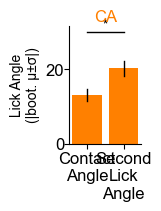

In [14]:
figName = 'Fig5_LickAngle.pdf'
nRows = 1
nCols = 1
hscalar = 1.5
vscalar = 2
figSize = [nCols*hscalar,nRows*vscalar]
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap\nmean±SEM"
elif error == 'std':
    errorLabel = "boot. μ±σ"
fontsize = 12
linewidth = 1
fig,ax=sled_general_tools.clean_subplots(nRows,nCols,figsize=figSize)
plt.subplots_adjust(wspace=0.1, hspace=0.2)

ylim = [0,32]
nBoot = 10000
base = np.zeros([len(anms),2])
usedAnimals = 0
for a, anm in enumerate(anms):
    anmData = allAnmParams[anm]
    tracker = anmData['tracker']
    me = anmData['me']
    cDists = []#anmData['cDists']
    sDists = []#anmData['sDists']
    for i, mod in enumerate(['c','s']):
        azi = anmData[f'{mod}Azi']
        ele = anmData[f'{mod}Ele']
        lda = anmData['lda']
        dists = jsm.get_lickAngle(azi, ele, lda)
        if i == 0:
            cDists = dists
        else:
            sDists = dists
    #anmR = np.zeros(4)

    #for p, phase in enumerate(['preShift_early','preShift_late','early','late']):
    phase = 'post'
    pMask = np.logical_and(allAnmParams[anm]['shiftMask'][phase], ~allAnmParams[anm]['aw'])
    if np.sum(pMask)>0:
        pT = tracker[pMask,:]
        pME = me[pMask]
        pCD = cDists[pMask]
        pSD = sDists[pMask]
        meMask = np.logical_and(pME,pT[:,2]==5)
        
        meCDist = np.nanmean(pCD[meMask])
        secondMask = np.logical_and(pSD, pSD<0)
        me2Dist = np.nanmean(pSD[secondMask])
        
        #dif = abs(meCDist)-abs(me2Dist)
        #anmR[p] = dif
        base[a,:] = np.hstack([meCDist, me2Dist])

        usedAnimals+=1
print('nAnm:', usedAnimals)

total = np.zeros([nBoot,2])

for i in range(nBoot):
    bAnms = np.random.choice(np.arange(usedAnimals), usedAnimals)
    total[i,:] = np.nanmean(base[bAnms,:], axis = 0)


mean = np.nanmean(total, axis=0)
med = np.nanmedian(total, axis=0)
std = np.nanstd(total, axis=0, ddof = 1)
sem = std / np.sqrt(total.shape[0])
low,high = np.nanpercentile(total, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
if error == 'CI':
    mainPlot = med
    errorLow = low
    errorHigh = high
elif error == 'sem':
    mainPlot = mean
    errorLow = mean-sem
    errorHigh = mean+sem
elif error == 'std':
    mainPlot = mean
    errorHigh = mean+std
    errorLow = mean-std

pVal = np.sum(abs(total[:,1])<abs(total[:,0]))/nBoot
print(f'{pVal:.03f}')
# if pVal<0.05:
#     pText = '*'
# else:
#     pText = 'n.s.'
pText = sled_stat_tools.pstar(pVal,inclP = False)
# ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha)
colors = [(1,0.5,0),(1,0.5,0)]
for i in range(2):
    ax.bar(i, abs(mean[i]), alpha = 1, color = colors[i])
    ax.plot([i]*2, abs(np.hstack([low[i],high[i]])), color = (0,0,0),lw=linewidth)
ax.set_xticks([0,1])
ax.set_xticklabels(['Contact\nAngle', 'Second\nLick\nAngle'])
ax.spines[['top','right']].set_visible(False)
ax.set_ylabel('Lick Angle\n(|'+errorLabel+'|)',fontsize=fontsize-2)
ax.tick_params(axis='both', which='major', labelsize=fontsize-4) #
ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #

ax.plot([0,1], [30]*2, color = (0,0,0),lw=linewidth)
ax.text(.5, 30, pText,color=(0,0,0),ha='center',va='bottom')

ax.text(0.5,ylim[1],'CA',color=colors[0],fontsize=fontsize,ha='center',va='bottom')

if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
sled_general_tools.display_clean_subplots(fig,ax)


[1.75, 2]
dendrites CR mean: 0.075 std: 0.145 pVal: 0.301
dendrites CA mean: -0.789 std: 0.384 pVal: 0.002
dendrites AP mean: -0.099 std: 0.142 pVal: 0.186
somas CR mean: 0.861 std: 0.305 pVal: 0.002
somas CA mean: -0.106 std: 0.192 pVal: 0.304
somas AP mean: -0.128 std: 0.198 pVal: 0.174


/tmp/ipykernel_3248419/542056944.py:26: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.1, hspace=0.2)


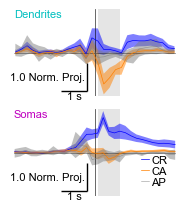

In [19]:
#Zach Edited
figName = "Fig5_MER_Projs.pdf"
#tsep3 = np.array([CR,AL_noME,AL_ME,AR,AN,DE,CL,SLR,SLL])
labels = ['CR','MER-CL', 'MER-MER', 'MER-CR', 'MER', 'MER-NA', 'DER', 'CL', 'CA', 'AP']
colors = [(0,0,1),'darkred',(0,0,0),'darkblue','darkblue',(0,0,0),'orange',(1,0,0),(1,0.5,0),(0.5,0.5,0.5)]
mod = 'CT'
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
niceAnatLabels = ['Dendrites', 'Somas']
nRows = 2
nCols = 1
hscalar = 1.75
vscalar = 1
figSize = [nCols*hscalar,nRows*vscalar]
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap\nmedian±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap\nmean±SEM"
elif error == 'std':
    errorLabel = "bootstrap\nmean±SD"
fontsize = 8
print(figSize)
# fig, axs = clean_subplots(nRows,nCols,figSize, sharey = True)
fig,axs=sled_general_tools.clean_subplots(nRows,nCols,figsize=figSize)
plt.subplots_adjust(wspace=0.1, hspace=0.2)

xlim = [-3.2,3.2]
xticks = [-3,-2,-1,0,1,2,3]
window = [3.6,4.6]
xspace = [-3.6,3.6]
MER_idx = -2
MER_FC_idx = -2
MER_FA_idx = -1
allDists = {}
ylim = [0,0]
plotTtypes = [0,MER_FC_idx,MER_FA_idx]
lineStyles = ['-','-',':']
lineDashes = [(0,0),(0,0),(1,0.5)]
plot_scaleBar={}
plot_scaleBar['corner']='BR'
plot_scaleBar['length_s'] = 1
plot_scaleBar['height_per'] = 0.4
plot_scaleBar['lw'] = 1
plot_scaleBar['vertAdjust']=0.1
plot_scaleBar['horzAdjust']=0.55
plot_scaleBar['fontsize'] = 8
plot_scaleBar['includeLabel'] = True
vertLabel = 'Norm. Proj.\n('+errorLabel+')'
vertLabel = 'Norm. Proj.'
clean = True
markerLS = '-'
markerLW = 0.5
markerColor = (0,0,0)
markerAlpha = 0.5
linewidth = 0.5


plotData = {}
for ak, anat in enumerate(anatKeys):
    F = frs[ak]/factors[ak]
    data = CRCA_HHscroll[anat]['post1'][mod]['projs']['post2'] #boot, trial, time
    ax = axs[ak]
    plotData[anat] = {}
    allDists[anat] = []
    winI = [int(F*window[0]),int(F*window[1])]
    denom = (np.nanmean(abs(data[:,0,winI[0]:winI[1]]), axis = 1)+np.nanmean(abs(data[:,MER_idx,winI[0]:winI[1]]), axis = 1))
    for t, ttype in enumerate(plotTtypes):
        trialTraces = data[:,ttype,:]/np.expand_dims(denom, axis = 1)
        # mean = np.nanmean(data[:,ttype,:], axis = 0)
        mean = np.nanmean(trialTraces, axis = 0)
        med = np.nanmedian(trialTraces, axis = 0)
        std = np.nanstd(trialTraces, axis = 0, ddof = 1)
        sem = std / np.sqrt(trialTraces.shape[0])
        low,high = np.nanpercentile(trialTraces, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
        x = np.linspace(xspace[0],xspace[1],len(mean))
        plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
        fr = x[1]-x[0]
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorHigh = mean+std
            errorLow = mean-std
        ylim[0] = np.nanmin([ylim[0],np.nanmin(errorLow)])
        ylim[1] = np.nanmax([ylim[1],np.nanmax(errorHigh)])
        winData = trialTraces[:,int(np.ceil(F*window[0])):int(np.ceil(F*window[1]))] #np.ceil
        if t == 0:
            pval = np.sum(winData.flatten()<0)/len(winData.flatten())
        else:
            pval = np.sum(winData.flatten()>0)/len(winData.flatten())
        pText = sled_stat_tools.pstar(pVal,inclP = False)
        print(anat, labels[ttype], f'mean: {np.nanmean(winData):.03f}', f'std: {np.nanstd(winData):.03f}',
              f'pVal: {pval:.03f}')
        plotData[anat][t] = {'fr':fr,'x':x,'plotIdx':plotIdx, 'mainPlot':mainPlot,'errorHigh':errorHigh,'errorLow':errorLow,'pval':pval,'color':colors[ttype],'label':labels[ttype]}
        

ylim[0] = ylim[0] + np.absolute(ylim[1]-ylim[0])*-0.02
ylim[1] = ylim[1] + np.absolute(ylim[1]-ylim[0])*0.02
for ak, ax in enumerate(axs):
    anat = anatKeys[ak]
    ax.axhline(0,lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
    F = frs[ak]/factors[ak]
    winF = x[int(F*window[0]):int(np.ceil(F*window[1]))]
    if winF[0]<0:
        winF = x[int(F*window[0])+1:int(np.ceil(F*window[1]))+1]
    ax.fill_between([winF[0],winF[-1]], [ylim[0]]*2, [ylim[1]]*2, color = (0,0,0), alpha = 0.1,linewidth=0,edgecolor='none')
    ax.axvline(0,lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
    ax.set_ylabel(f'{niceAnatLabels[ak]}\nNorm. Proj. (a.u.)',fontsize=fontsize,labelpad=0)
    if mod == 'GO':
        alignTime = 'Go Cue'
        markers = [0,-1.25,-2.45]
    elif mod == 'LL':
        alignTime = 'Last Lick'
        markers = [0]
    else:
        alignTime = 'Contact'
        markers = [0]
    for mark in markers:
        ax.plot([mark]*2,ylim,ls='-',alpha=0.5,color=(0,0,0),linewidth=0.5)
    ax.set_xlabel(f'Time Relative to {alignTime} (s)',fontsize=fontsize,labelpad=0)
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.spines[['top','right']].set_visible(False)
    ax,plot_scaleBar = sled_ROI_tools.add_plot_scaleBar(ax,plot_scaleBar,(0,0,0),True,vertLabel)
for ak, anat in enumerate(anatKeys):

    for t, ttype in enumerate(plotTtypes):
        axs[ak].fill_between(plotData[anat][t]['x'][plotData[anat][t]['plotIdx']], \
                             plotData[anat][t]['errorLow'][plotData[anat][t]['plotIdx']], \
                             plotData[anat][t]['errorHigh'][plotData[anat][t]['plotIdx']], \
                             color = plotData[anat][t]['color'], alpha = 0.5,linewidth=0,edgecolor='none')
        if lineStyles[t] == '-':
            axs[ak].plot(plotData[anat][t]['x'][plotData[anat][t]['plotIdx']], plotData[anat][t]['mainPlot'][plotData[anat][t]['plotIdx']],\
                         color = plotData[anat][t]['color'], label = plotData[anat][t]['label'],lw = linewidth, ls = lineStyles[t])
        else:
            axs[ak].plot(plotData[anat][t]['x'][plotData[anat][t]['plotIdx']], plotData[anat][t]['mainPlot'][plotData[anat][t]['plotIdx']],\
                         color = plotData[anat][t]['color'], label = plotData[anat][t]['label'],lw = linewidth, ls = lineStyles[t], dashes = lineDashes[t])
            
    axs[ak].set_ylim(ylim)
    axs[ak].text(xlim[0],ylim[1], niceAnatLabels[ak], color = aColors[ak], fontsize=fontsize,ha='left',va='top')
    axs[ak].tick_params(axis='both', which='major', labelsize=fontsize) #
    if ak == 1:
        loc = 'lower right'
        axs[ak].legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 
    if clean:
        axs[ak].spines[['bottom','left']].set_visible(False)
        axs[ak].set_xticks([])
        axs[ak].set_yticks([])
        axs[ak].set_xlabel('')
        axs[ak].set_ylabel('')

if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
sled_general_tools.display_clean_subplots(fig,axs)


/tmp/ipykernel_3248419/3125313984.py:12: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.1, hspace=0.2)


dendrites
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.2616 0.0064 0.1856]
pVals_Corr = [0.3712 0.0192 0.3712]

dendrites CR mean: 0.156 std: 0.143
dendrites CA mean: -0.759 std: 0.177
dendrites AP mean: -0.120 std: 0.101

somas
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.     0.4498 0.0576]
pVals_Corr = [0.     0.4498 0.1152]

somas CR mean: 0.872 std: 0.078
somas CA mean: -0.073 std: 0.098
somas AP mean: -0.122 std: 0.098

MultCompar Correction method = holm alpha = 0.05
pVals      = [0.0012 0.0192 0.99  ]
pVals_Corr = [0.0036 0.0384 0.99  ]


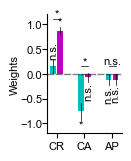

In [20]:
#ZACH Version
#fig, axs = clean_subplots(1,2,[6,4], sharey = False, constrained_layout = True)
figName = "Fig5_Weights.pdf"
labels = ['CR','MER-CL', 'MER-MER', 'MER-CR', 'MER', 'MER-NA', 'DER', 'CL', 'CA', 'AP']
colors = [(0,0,1),'darkred',(0,0,0),'darkblue','darkblue',(0,0,0),'orange',(1,0,0),(0.7,0.7,0.7),(0.31,0.31,0.31)]

nCols = 1
nRows = 1
fontsize = 8
figSize = (1.2,1.5)
fig,ax=sled_general_tools.clean_subplots(nRows,nCols,figsize=figSize)
plt.subplots_adjust(wspace=0.1, hspace=0.2)


MER_idx = -2
linewidth = 0.5
offsets = [2,1]
barwidth = 0.1
pLabels = ['Early', 'Late','Late-Early']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"
niceAnatLabels = ['Dendrites','Somas']
window = [3.6,4.7]
testLS = ':'
testDashes = (5,1)
testLW = 1
testColor = (0,0,0)
testAlpha = 0.5

allDists = {}
plotIdxs = [0,-2,-1]
alphas = [1,1,1]
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
testLine = 0
ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha, dashes=testDashes)
for ak, anat in enumerate(anatKeys):
    data = CRCA_HHscroll[anat]['post1'][mod]['projs']['post2'] #boot, trial, time
    F = frs[ak]/factors[ak]
    allDists[anat] = []

    x = np.linspace(-3.6,3.6,data.shape[2])
    winF = x[int(F*window[0]):int(np.ceil(F*window[1]))]
    winI = [int(F*window[0]),int(np.ceil(F*window[1]))]
    if winF[0]<0:
        winF = x[int(F*window[0])+1:int(np.ceil(F*window[1]))+1]
        winI = [int(F*window[0])+1,int(np.ceil(F*window[1]))+1]
    
    denom = (np.nanmean(abs(data[:,plotIdxs[0],winI[0]:winI[1]]), axis = 1)+np.nanmean(abs(data[:,plotIdxs[1],winI[0]:winI[1]]), axis = 1))
    pVals = []
    for t, ttype in enumerate(plotIdxs):
        wData = np.nanmean(data[:,ttype,winI[0]:winI[1]], axis = 1)/denom

        allDists[anat].append(wData)

        mean = np.nanmean(wData)
        med = np.nanmedian(wData)
        std = np.nanstd(wData, ddof = 1)
        sem = std / np.sqrt(wData.shape[0])
        low,high = np.nanpercentile(wData, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))])
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorLow = mean-std
            errorHigh = mean+std
        
        testLine = 0
            
        tail1 = np.sum(wData<testLine)/wData.shape[0]
        tail2 = np.sum(wData>testLine)/wData.shape[0]
        twoTails = 2 * min(tail1, tail2)
        pVal = min(twoTails, 1.0)
        pText = sled_stat_tools.pstar(pVal,inclP = False)
        pVals.append(pVal)

        x = (ak/4)+t

        if mainPlot<testLine:
            text_ypos = errorLow
            va='top'
        else:
            text_ypos = errorHigh
            va = 'bottom'
        ax.bar(x, mainPlot, width = 0.2, color = aColors[ak], alpha = alphas[ak])

        ax.plot([x,x],[errorLow,errorHigh], color = (0,0,0),lw = linewidth)

    print(anat)
    anatPCorr,pText = sled_stat_tools.multi_test_correction(pVals,method='holm',alpha = 0.05,verbose = True)
    print('')
    for t, ttype in enumerate(plotIdxs):
        anatPTtype = anatPCorr['pvals_corrected'][t]
        ttypePText = pText[t]
        
        wData = np.nanmean(data[:,ttype,winI[0]:winI[1]], axis = 1)/denom
        mean = np.nanmean(wData)
        med = np.nanmedian(wData)
        std = np.nanstd(wData, ddof = 1)
        sem = std / np.sqrt(wData.shape[0])
        low,high = np.nanpercentile(wData, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))])
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorLow = mean-std
            errorHigh = mean+std
        
        testLine = 0
        x = (ak/4)+t

        if mainPlot<testLine:
            text_ypos = errorLow
            va='top'
        else:
            va='bottom'
            text_ypos = errorHigh

        if 'n.s.' in ttypePText:
            ax.text(x, text_ypos, ttypePText,fontsize=fontsize,ha='center',va=va,rotation=90)
        else:
            ax.text(x, text_ypos, ttypePText,fontsize=fontsize,ha='center',va=va,rotation=0)

        print(anat, labels[ttype], f'mean: {mean:.03f}',f'std: {std:.03f}')#, f'pval: {anatPType:03f}')
    print('')
    
ax.spines[['top','right']].set_visible(False)
ax.set_ylim([-1.2,1.2])
ys = [1.1,.15,.15]
pVals = []
for w in range(3):
    dData = allDists['dendrites'][w]
    sData = allDists['somas'][w]

    tail1 = np.sum(dData<sData)/dData.shape[0]
    tail2 = np.sum(dData>sData)/dData.shape[0]
    twoTails = 2 * min(tail1, tail2)
    pVal = min(twoTails, 1.0)
    # print(pVal)
    pVals.append(pVal)

multCorr,pText = sled_stat_tools.multi_test_correction(pVals,method='holm',alpha = 0.05,verbose = True)

for w in range(3):
    y = ys[w]
    ax.plot([w,w+0.25],[y,y], lw = linewidth, color = (0,0,0))
    ax.text(w+.125,y,pText[w],fontsize=fontsize,ha='center',va='bottom')
   #print(w, f'{multCorr[w]:.03f}')
ax.set_xticks(np.arange(3)+.12)
ax.set_xticklabels(['CR','CA','AP'])
ax.set_yticks([-1,-0.5,0,0.5,1])
ax.set_ylabel('Weights\n('+errorLabel+')',fontsize=fontsize,labelpad=0)
ax.set_ylabel('Weights',fontsize=fontsize,labelpad=0)
ax.tick_params(axis='both', which='major', labelsize=fontsize) #
ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #

if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
sled_general_tools.display_clean_subplots(fig,ax)


# Fig5 Supplement

In [22]:
mod = 'CT'
window = [3.6,4.6]
normFactors = {}
for ak, anat in enumerate(anatKeys):
    F = frs[ak]/factors[ak]
    winI = [int(F*window[0]),int(F*window[1])]
    normFactors[anat] = {}

    normFactors[anat]['CR-CA'] = {}

    # axesOrig = (boot x time x ROI)
    normFactors[anat]['CR-CA']['norms'] = np.linalg.norm(CRCA_HHscroll[anat]['post1'][mod]['axesOrig'], axis=2, keepdims=False)
    # norms = boot x time
    normFactors[anat]['CR-CA']['normFactor'] = np.nanmean(normFactors[anat]['CR-CA']['norms'][:,winI[0]:winI[1]])
    print(f'CR-CA {anat} {normFactors[anat]["CR-CA"]["normFactor"]:.3f}')
    
    normFactors[anat]['CR-CL'] = {}
    # axesOrig = (boot x time x ROI)
    normFactors[anat]['CR-CL']['norms'] = np.linalg.norm(CRCL_HHscroll[anat]['post1'][mod]['axesOrig'], axis=2, keepdims=False)
    # norms = boot x time
    normFactors[anat]['CR-CL']['normFactor'] = np.nanmean(normFactors[anat]['CR-CL']['norms'][:,winI[0]:winI[1]])
    print(f'CR-CL {anat} {normFactors[anat]["CR-CL"]["normFactor"]:.3f}')
    
    normFactors[anat]['AP-CA'] = {}
    # axesOrig = (boot x time x ROI)
    normFactors[anat]['AP-CA']['norms'] = np.linalg.norm(APCA_HHscroll[anat]['post1'][mod]['axesOrig'], axis=2, keepdims=False)
    # norms = boot x time
    normFactors[anat]['AP-CA']['normFactor'] = np.nanmean(normFactors[anat]['AP-CA']['norms'][:,winI[0]:winI[1]])
    print(f'CR-CL {anat} {normFactors[anat]["CR-CL"]["normFactor"]:.3f}')

    normFactors[anat]['[CR-CA]/[CR-CL]'] = normFactors[anat]['CR-CA']['normFactor'] / normFactors[anat]['CR-CL']['normFactor']
    normFactors[anat]['[AP-CA]/[CR-CL]'] = normFactors[anat]['AP-CA']['normFactor'] / normFactors[anat]['CR-CL']['normFactor']

    print(f'[CR-CA]/[CR-CL] {anat} {normFactors[anat]["[CR-CA]/[CR-CL]"]:.3f}')
    print(f'[AP-CA]/[CR-CL] {anat} {normFactors[anat]["[AP-CA]/[CR-CL]"]:.3f}')


CR-CA dendrites 2.893
CR-CL dendrites 2.767
CR-CL dendrites 2.767
[CR-CA]/[CR-CL] dendrites 1.046
[AP-CA]/[CR-CL] dendrites 1.499
CR-CA somas 6.212
CR-CL somas 9.384
CR-CL somas 9.384
[CR-CA]/[CR-CL] somas 0.662
[AP-CA]/[CR-CL] somas 1.010


In [25]:
scaleTraces= True
labels = ['CR','MER-CL', 'MER-MER', 'MER-CR', 'MER', 'MER-NA', 'DER', 'CL', 'CA', 'AP']
colors = [(0,0,1),(0.3,0.3,0.3),(0.7,0.2,0),(1,0.5,0),(1,0.5,0),(0.6,0.6,0.6),(1,0.5,0.5),(1,0,0),(1,0.5,0),(0.5,0.5,0.5)]
mod = 'CT'
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
niceAnatLabels = ['Dendrites', 'Somas']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap\nmedian±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap\nmean±SEM"
elif error == 'std':
    errorLabel = "bootstrap\nmean±SD"
fontsize = 8
xlim = [-3.2,3.2]
xticks = [-3,-2,-1,0,1,2,3]
window = [3.6,4.6]
xspace = [-3.6,3.6]
CR_idx = 0
CL_idx = 7
CA_idx = -2
AP_idx = -1
linewidth = 0.5
markerLS = '-'
markerLW = 0.5
markerColor = (0,0,0)
markerAlpha = 0.5
hscalar = 1.25
vscalar = 1.25
ylims = [-2.5,2.5]
yticks = [-2,-1,0,1,2]
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.2,
    hspace=0.2
)
nCols = 5
nRows = 2
sharex = True
sharey = True
loc = 'lower left'
clean = False
plot_scaleBar={}
plot_scaleBar['corner']='BR'
plot_scaleBar['length_s'] = 1
plot_scaleBar['height_per'] = 0.25
plot_scaleBar['lw'] = 1
plot_scaleBar['vertAdjust']=0.75
plot_scaleBar['horzAdjust']=0.02
plot_scaleBar['fontsize'] = 8
plot_scaleBar['includeLabel'] = True
if scaleTraces:
    vertLabel = 'Scaled,\nNorm. Proj.'
    yLabel = 'Scaled, Norm.\nProj. (a.u.)'
else:
    vertLabel = 'Norm. Proj.'
    yLabel = 'Norm. Proj. (a.u.)'
manualYlim = True
reverseLeg = True

figure_size_in:
  width[<class 'float'>]: 6.25
  height[<class 'float'>]: 2.5
axes_size_in:
  width[<class 'float'>]: 0.9698275862068965
  height[<class 'float'>]: 1.0227272727272727
margins_in:
  left[<class 'float'>]: 0.3125
  right[<class 'float'>]: 0.3125000000000003
  bottom[<class 'float'>]: 0.125
  top[<class 'float'>]: 0.1250000000000001
spacing_in:
  wspace[<class 'float'>]: 0.1939655172413793
  hspace[<class 'float'>]: 0.20454545454545456
dendrites CR(CR) 0.006
dendrites CL(CL) 0.003
somas CR(CR) 0.0
somas CL(CL) 0.025


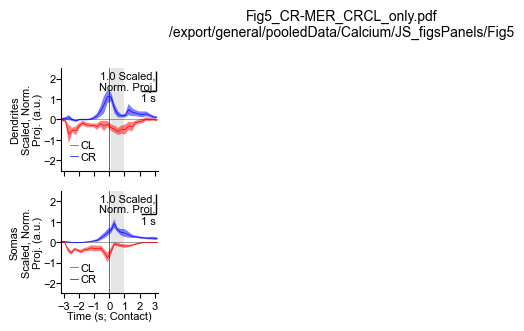

In [29]:
figName = "Fig5_CR-MER_CRCL_only.pdf"
plotTtypes = [[0,7]]
plotTtypeLabels = [['CR','CL']]
dataSource= ['CRCL_HHscroll'] #pick which source to use
normMethod = ['CR+CL']
colScaling = [False]
ratio = '[CR-CA]/[CR-CL]'
lineStyles = [['-','-']]
lineDashes = [[(0,0),(0,0)]]
#########################################################################
jsm.plot_CD_projections(nRows,nCols,mod,colors,labels,niceAnatLabels,plot_scaleBar, plotTtypes, plotTtypeLabels, dataSource, normMethod, colScaling, normFactors, ratio, CR_idx, CA_idx, AP_idx, CL_idx, CRCA_HHscroll, APCA_HHscroll, CRCL_HHscroll, anatKeys, frs, factors, window, xspace, xlim, error, CI, nBoots, sharex, sharey, gridspec_kw, vscalar, hscalar)

figure_size_in:
  width[<class 'float'>]: 6.25
  height[<class 'float'>]: 2.5
axes_size_in:
  width[<class 'float'>]: 0.9698275862068965
  height[<class 'float'>]: 1.0227272727272727
margins_in:
  left[<class 'float'>]: 0.3125
  right[<class 'float'>]: 0.3125000000000003
  bottom[<class 'float'>]: 0.125
  top[<class 'float'>]: 0.1250000000000001
spacing_in:
  wspace[<class 'float'>]: 0.1939655172413793
  hspace[<class 'float'>]: 0.20454545454545456
colScaling dendrites ['AP', 'CA', 'CR'] x1.0455795481176862
dendrites AP(AP) 0.813
colScaling dendrites ['AP', 'CA', 'CR'] x1.0455795481176862
dendrites CA(CA) 0.002
colScaling dendrites ['AP', 'CA', 'CR'] x1.0455795481176862
dendrites CR(CR) 0.699
colScaling somas ['AP', 'CA', 'CR'] x0.6619249335281063
somas AP(AP) 0.826
colScaling somas ['AP', 'CA', 'CR'] x0.6619249335281063
somas CA(CA) 0.304
colScaling somas ['AP', 'CA', 'CR'] x0.6619249335281063
somas CR(CR) 0.998
colScaling dendrites ['CA(LC)', 'CA(RC)'] x1.0455795481176862
dendrites C

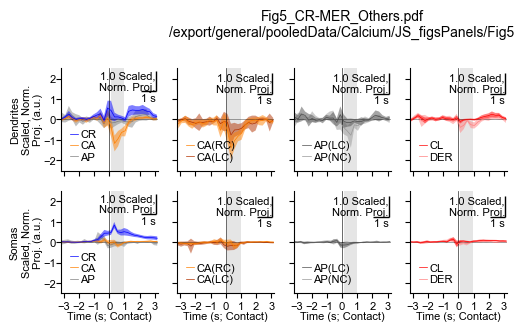

In [30]:
figName = "Fig5_CR-MER_Others.pdf"
plotTtypes = [[9,8,0],[2,3],[5,1],[6,7]]
plotTtypeLabels = [['AP','CA','CR'],['CA(LC)','CA(RC)'],['AP(NC)','AP(LC)'],['DER','CL']]
dataSource= ['CRCA_HHscroll','CRCA_HHscroll','CRCA_HHscroll','CRCA_HHscroll'] #pick which source to use
normMethod = ['CR+CA','CR+CA','CR+CA','CR+CA']
colScaling = [True,True,True,True]
ratio = '[CR-CA]/[CR-CL]'
lineStyles = [['-','-','-'],['-','-'],['-','-'],['-','-']]
lineDashes = [[(0,0),(0,0),(0,0)],[(0,0),(0,0)],[(0,0),(0,0)],[(0,0),(0,0)]]
#########################################################################
jsm.plot_CD_projections(nRows,nCols,mod,colors,labels,niceAnatLabels,plot_scaleBar, plotTtypes, plotTtypeLabels, dataSource, normMethod, colScaling, normFactors, ratio, CR_idx, CA_idx, AP_idx, CL_idx, CRCA_HHscroll, APCA_HHscroll, CRCL_HHscroll, anatKeys, frs, factors, window, xspace, xlim, error, CI, nBoots, sharex, sharey, gridspec_kw, vscalar, hscalar)

### raw trials correlation

In [14]:
allAnm2L = {}
for ak, anat in enumerate(anatKeys):
    anat2L = []
    for anm in list(bothAnms[anat]):
        tracker = allAnmParams[anm]['tracker']
        me = allAnmParams[anm]['me']

        sTimes = allAnmParams[anm]['sTimes']
        goCues = allAnmParams[anm]['goCues']
        cTimes = allAnmParams[anm]['cTimes']
        
        sRelToG = sTimes+goCues
        sRelToC = sRelToG-cTimes

        meM = np.logical_and(me, tracker[:,2]==5)
        meM = np.logical_and(meM, allAnmParams[anm]['shiftMask']['post'])
        anat2L.append(np.nanmean(sRelToC[meM]))
    allAnm2L[anat] = np.nanmean(anat2L)

In [15]:
allRawImgs = {}
ttype1 = 0
ttype2 = 8
for mod in ['CT']:#,'SL']:
    allRawImgs[mod] = {}
    for ak, anat in enumerate(anatKeys):
        aImgs = []
        for i in tqdm(range(nBoot), desc = f'{mod} {anat}'):
            A = megaTsepsHH["post1"][f'err{mod}'][anat][ttype1,:,:,i]
            B = megaTsepsHH["post2"][f'err{mod}'][anat][ttype2,:,:,i]
            nTime = A.shape[0] #time, roi
            halfTime = nTime/2
            mat = np.zeros([nTime, nTime])
            for i in range(nTime):
                for j in range(nTime):
                    mat[i,j] = pearsonr(A[i,:], B[j,:])[0]
            aImgs.append(mat)
        allRawImgs[mod][anat] = np.dstack(aImgs)
        


CT somas: 100%|██████████| 10000/10000 [04:49<00:00, 34.58it/s]


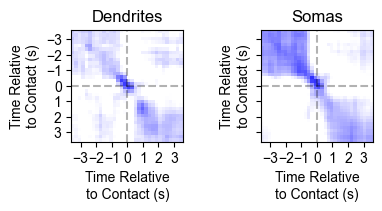

In [21]:
fig,axs=sled_general_tools.clean_subplots(1,2,figsize=[4,2],sharex=True,sharey=True)
tmin, tmax = -3.6, 3.6
ticks = [-3,-2,-1,0,1,2,3]
ColorScalar = 1000
rcmap = [(1,1,1),(0,0,1)]
cmap,tempRGB,tempBGR = sled_image_tools.generate_cmap(rcmap,ColorScalar,cmap_name='cmap')
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
niceAnatLabels = ['Dendrites', 'Somas']
for m, mod in enumerate(allRawImgs.keys()):
    if mod == 'CT':
        modLabel = 'Contact'
    else:
        modLabel = 'Second Contact'
    for ak, anat in enumerate(anatKeys):
        if len(list(allRawImgs.keys()))==1:
            ax = axs[ak]
            shrink = 0.79
        else:
            ax = axs[ak,m]
            shrink = .68
        ax.set_title(f'{niceAnatLabels[ak]}')
        img = np.nanmedian(allRawImgs[mod][anat], axis = 2)
        img_RGB = sled_image_tools.convert2RGB(img,0,1,cmap,ColorScalar)
        im = ax.imshow(img_RGB, extent=[tmin,tmax,tmax,tmin],interpolation='none')
        
        ax.axvline(0, color = (0,0,0), linestyle = '--', alpha = 0.3)

        ax.axhline(0, color = (0,0,0), linestyle = '--', alpha = 0.3)
        for item in [ax.set_xlabel, ax.set_ylabel]:
            item(f'Time Relative\nto {modLabel} (s)')
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
figName = 'MERSupp_CRCA_Correlation.pdf'
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
sled_general_tools.display_clean_subplots(fig,axs)


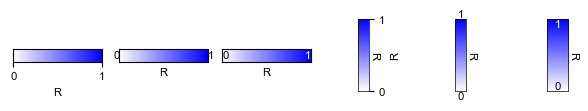

In [23]:
style = 'end'
figName = 'fig5_pearson_cmap.pdf'
sled_image_tools.export_colorbar_new(rcmap,style,figName,figSaveDir,figsize = (6,1), fontsize=8, lw = 0.5, label = 'R',minVal=0,midVal = 0,maxVal = 1)
